### Aqui será feita a análise exploratória dos dados do Fogo Cruzado, a nossa principal fonte de dados sobre ocorrências de violência no RJ

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

In [ ]:
crossfire_data_path = r"..\data\raw\fogo_cruzado\fc_api_occurrences_with_victims_2026-04-30T13_07_37.000Z.csv"
crossfire_df = pd.read_csv(crossfire_data_path)

Primeiro buscamos informações iniciais sobre o dataframe

In [4]:
crossfire_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28262 entries, 0 to 28261
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    28262 non-null  int64  
 1   address               28262 non-null  str    
 2   region                28262 non-null  str    
 3   state                 28262 non-null  str    
 4   city                  28262 non-null  str    
 5   neighborhood          28262 non-null  str    
 6   sub_neighborhood      161 non-null    str    
 7   locality              19927 non-null  str    
 8   latitude              28262 non-null  float64
 9   longitude             28262 non-null  float64
 10  data                  28262 non-null  str    
 11  police_action         28262 non-null  bool   
 12  agent_presence        28262 non-null  bool   
 13  police_unit           7938 non-null   str    
 14  main_reason           28262 non-null  str    
 15  complementary_reason  0 non-nu

In [5]:
crossfire_df.columns

Index(['id', 'address', 'region', 'state', 'city', 'neighborhood',
       'sub_neighborhood', 'locality', 'latitude', 'longitude', 'data',
       'police_action', 'agent_presence', 'police_unit', 'main_reason',
       'complementary_reason', 'clippings', 'massacre', 'civilians_dead',
       'civilians_wounded', 'agents_dead', 'agents_wounded', 'men_dead',
       'men_wounded', 'women_dead', 'women_wounded', 'kids_dead',
       'kids_wounded', 'teenagers_dead', 'teenagers_wounded', 'elderly_dead',
       'elderly_wounded'],
      dtype='str')

### Remoção de colunas desnecessárias
Removeremos algumas colunas que não serão uteis, como as que representam grupos que foram feridos (crianças, adolescentes, idosos etc). 
Porém usaremos 'civilians_dead' e'civilians_wounded', representando civis que foram feridos ou mortos, por simplicidade.
<br>
Também removeremos colunas de localização (como região, endereço..), pois não serão úteis ou são redundantes, assim como as que possuem muitos valores nulos (e que não seriam úteis), como 'complementary_reason', "police_unit", "clippings".

In [6]:
crossfire_df.drop(["address","region","state","city",'locality',"sub_neighborhood",'complementary_reason', "police_unit", "clippings",'agents_dead', 'agents_wounded',
       'men_dead', 'men_wounded', 'women_dead', 'women_wounded', 'kids_dead',
       'kids_wounded', 'teenagers_dead', 'teenagers_wounded', 'elderly_dead',
       'elderly_wounded'], axis=1, inplace=True)
crossfire_df.head()

,id,neighborhood,latitude,longitude,data,police_action,agent_presence,main_reason,massacre,civilians_dead,civilians_wounded
0,5318,COMPLEXO DO ALEMAO,-22.866065,-43.272438,"04/07/2016, 21:00:00",True,True,Ação policial,False,0,0
1,5325,CIDADE DE DEUS,-22.948170,-43.362671,"04/07/2016, 21:00:00",True,True,Ação policial,False,0,0
2,69,SAMPAIO,-22.901310,-43.263218,"04/07/2016, 21:40:00",False,False,Não identificado,False,0,0
3,16,SANTA CRUZ,-22.919651,-43.684387,"05/07/2016, 03:02:00",True,True,Operação policial,False,0,0
4,229,ACARI,-22.825531,-43.344460,"05/07/2016, 08:50:00",True,True,Operação policial,False,0,0


Criaremos tabelas que representam o tempo, para o fator sazonalidade na penalidade do modelo do Graphhopper

In [7]:
dt = pd.to_datetime(crossfire_df["data"], dayfirst=True, errors="coerce")
crossfire_df["data_timestamp"] = dt.dt.normalize()
crossfire_df["hora_timestamp"] = dt.dt.time
crossfire_df["hora"] = pd.to_datetime(
    crossfire_df["hora_timestamp"].astype(str),
    errors="coerce"
).dt.hour

crossfire_df.head()

C:\Users\Pichau\AppData\Local\Temp\ipykernel_15884\4082304282.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crossfire_df["hora"] = pd.to_datetime(


,id,neighborhood,latitude,longitude,data,police_action,agent_presence,main_reason,massacre,civilians_dead,civilians_wounded,data_timestamp,hora_timestamp,hora
0,5318,COMPLEXO DO ALEMAO,-22.866065,-43.272438,"04/07/2016, 21:00:00",True,True,Ação policial,False,0,0,2016-07-04,21:00:00,21
1,5325,CIDADE DE DEUS,-22.948170,-43.362671,"04/07/2016, 21:00:00",True,True,Ação policial,False,0,0,2016-07-04,21:00:00,21
2,69,SAMPAIO,-22.901310,-43.263218,"04/07/2016, 21:40:00",False,False,Não identificado,False,0,0,2016-07-04,21:40:00,21
3,16,SANTA CRUZ,-22.919651,-43.684387,"05/07/2016, 03:02:00",True,True,Operação policial,False,0,0,2016-07-05,03:02:00,3
4,229,ACARI,-22.825531,-43.344460,"05/07/2016, 08:50:00",True,True,Operação policial,False,0,0,2016-07-05,08:50:00,8


In [8]:
def periodo_dia(hora):
    if 0 <= hora < 6:
        return 'Madrugada'
    elif 6 <= hora < 12:
        return 'Manhã'
    elif 12 <= hora < 18:
        return 'Tarde'
    else:
        return 'Noite'

crossfire_df['turno'] = crossfire_df['hora'].apply(periodo_dia)

In [9]:
crossfire_df.columns #Colunas com quais trabalharemos

Index(['id', 'neighborhood', 'latitude', 'longitude', 'data', 'police_action',
       'agent_presence', 'main_reason', 'massacre', 'civilians_dead',
       'civilians_wounded', 'data_timestamp', 'hora_timestamp', 'hora',
       'turno'],
      dtype='str')

In [10]:
crossfire_df.describe()

,id,latitude,longitude,civilians_dead,civilians_wounded,data_timestamp,hora
count,28262.000000,28262.000000,28262.000000,28262.000000,28262.000000,28262,28262.000000
mean,32726.387021,-22.887871,-43.328051,0.152749,0.163364,2020-05-18 22:10:21.102540,12.138773
min,16.000000,-23.062066,-43.718054,0.000000,0.000000,2016-07-04 00:00:00,0.000000
25%,14130.500000,-22.916930,-43.369720,0.000000,0.000000,2018-05-10 00:00:00,6.000000
50%,30236.500000,-22.883636,-43.315278,0.000000,0.000000,2019-08-28 00:00:00,13.000000
75%,49684.750000,-22.857810,-43.254520,0.000000,0.000000,2022-05-15 00:00:00,18.000000
max,77086.000000,-22.774151,-43.152561,117.000000,11.000000,2026-04-30 00:00:00,23.000000
std,21664.550249,0.045617,0.100112,0.900003,0.536577,NaN,6.702940


Checagem de nulos <br>
Boa noticia: não há nenhum!

In [11]:
crossfire_df.isna().sum()

id                   0
neighborhood         0
latitude             0
longitude            0
data                 0
police_action        0
agent_presence       0
main_reason          0
massacre             0
civilians_dead       0
civilians_wounded    0
data_timestamp       0
hora_timestamp       0
hora                 0
turno                0
dtype: int64

### Com os dados preparados, podemos começar a analisar a distribuição deles

In [12]:
crossfire_df['neighborhood'].value_counts().head(10) #Quais os bairros com mais ocorrências?

neighborhood
VILA KENNEDY           1558
COMPLEXO DO ALEMAO     1108
PRACA SECA             1089
CIDADE DE DEUS         1071
TIJUCA                  878
MARE                    814
BANGU                   750
VICENTE DE CARVALHO     581
PENHA                   563
MADUREIRA               556
Name: count, dtype: int64

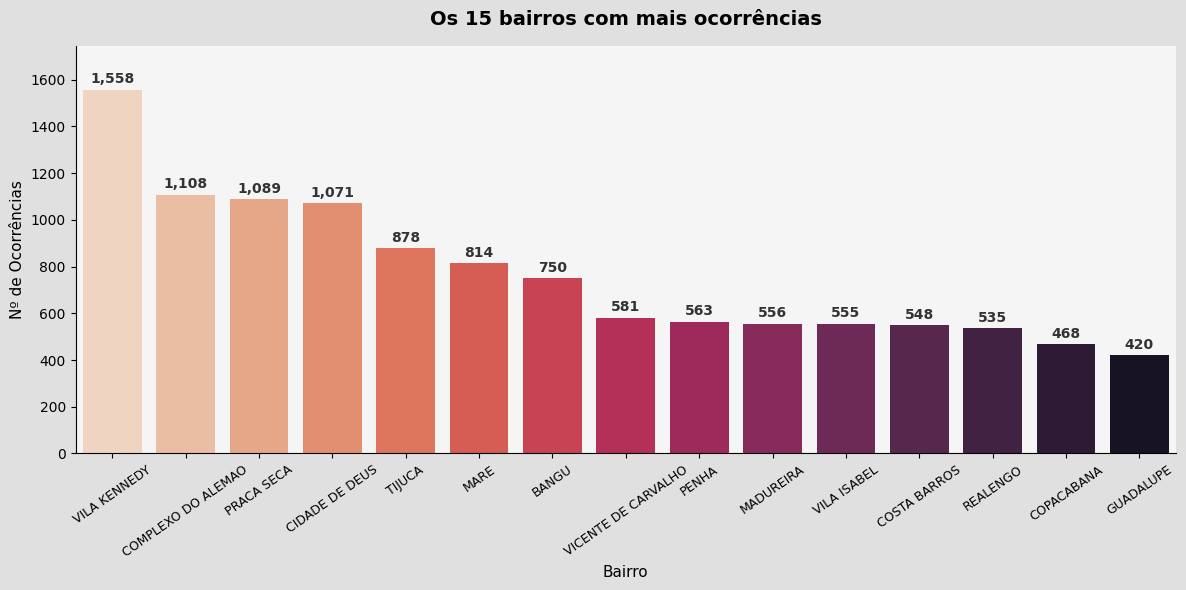

In [13]:
top10 = crossfire_df['neighborhood'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(12, 6))
palette = sns.color_palette("rocket_r", n_colors=len(top10))
sns.barplot(x=top10.index, y=top10.values, hue=top10.index, palette=palette, legend=False, ax=ax)

for bar, value in zip(ax.patches, top10.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f'{value:,}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#333333'
    )

ax.set_title('Os 15 bairros com mais ocorrências', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Bairro', fontsize=11)
ax.set_ylabel('Nº de Ocorrências', fontsize=11)
ax.set_ylim(0, top10.values.max() * 1.12)
sns.despine()
fig.patch.set_facecolor("#e0e0e0")
ax.set_facecolor("#f5f5f5")
ax.set_xticks(range(len(top10.index)))
ax.set_xticklabels(top10.index, rotation=35, ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [14]:
crossfire_df['civilians_dead'].value_counts()

civilians_dead
0      25281
1       2281
2        451
3        143
4         55
5         17
6         16
7          5
8          4
10         2
12         1
13         1
27         1
9          1
23         1
16         1
117        1
Name: count, dtype: int64

89% das ocorrências não possuem morte de civis, mas há um outlier com 117 mortes

In [15]:
crossfire_df[crossfire_df['civilians_dead'] == 117]

,id,neighborhood,latitude,longitude,data,police_action,agent_presence,main_reason,massacre,civilians_dead,civilians_wounded,data_timestamp,hora_timestamp,hora,turno
27628,74284,PENHA,-22.848027,-43.28614,"28/10/2025, 02:00:00",True,True,Operação policial,True,117,9,2025-10-28,02:00:00,2,Madrugada


A data 2025-10-28 indica que foi a Operação Contenção, a operação mais letal do Brasil, explicando o outlier (talvez afete o modelo).

In [16]:
len(crossfire_df[crossfire_df['civilians_dead'] == 0])/len(crossfire_df)*100

89.45226806312363

In [17]:
crossfire_df['civilians_wounded'].value_counts()

civilians_wounded
0     24977
1      2397
2       620
3       180
4        47
5        18
6        14
8         4
9         2
11        1
10        1
7         1
Name: count, dtype: int64

88% das ocorrências não possuem morte de civis

In [18]:
len(crossfire_df[crossfire_df['civilians_wounded'] == 0])/len(crossfire_df)*100

88.3766187814026

In [19]:
crossfire_df['police_action'].value_counts()

police_action
False    20334
True      7928
Name: count, dtype: int64

In [20]:
len(crossfire_df[crossfire_df['police_action'] == True])/len(crossfire_df)*100

28.051801004882883

In [21]:
crossfire_df['agent_presence'].value_counts()

agent_presence
False    19446
True      8816
Name: count, dtype: int64

In [22]:
len(crossfire_df[crossfire_df['agent_presence'] == True])/len(crossfire_df)*100

31.193829169910124

~30% dos casos tinham policiais agindo ou agentes presentes

In [39]:
Quant_ambos = len(crossfire_df[(crossfire_df['agent_presence'] == True) & (crossfire_df['police_action'] == True)]) #Quantas ocorrências teve ambos
Quant_pelo_menos = len(crossfire_df[(crossfire_df['agent_presence'] == True) | (crossfire_df['police_action'] == True)]) #Quantas ocorrências teve pelo menos um dos dois
Quant_ambos / Quant_pelo_menos *100

89.92740471869328

90% das ocorrências que tinham ação policial ou agente presente, tinha ambos. <br>
(isso explica a % de ambos serem parecidas [em torno de 30%])

Distribuição por ano (2026 em aberto)

In [23]:
crossfire_df.groupby(crossfire_df["data_timestamp"].dt.year).size()

data_timestamp
2016    1604
2017    3565
2018    5700
2019    4344
2020    2724
2021    2503
2022    2176
2023    1974
2024    1690
2025    1570
2026     412
dtype: int64

Causas das ocorrências

In [24]:
crossfire_df["main_reason"].unique()

<StringArray>
[            'Ação policial',          'Não identificado',
         'Operação policial',           'Tentativa/Roubo',
       'Homicidio/Tentativa',                   'Disputa',
              'Tiros a esmo',            'Ataque a civis',
 'Tentativa/Roubo de cargas',                     'Briga',
 'Sequestro/Cárcere Privado',                  'Arrastão',
   'Tentativa/Roubo a banco',         'Disparo Acidental',
                   'Tortura',                  'Suicídio',
                     'Outro']
Length: 17, dtype: str

A maioria (60%) das causas das ocorrências é dada como "Não identificado", o que pode prejudicar a análise

In [25]:
crossfire_df.groupby("main_reason").size().sort_values(ascending=False)

main_reason
Não identificado             17037
Ação policial                 4332
Operação policial             2783
Tentativa/Roubo               1501
Disputa                        994
Homicidio/Tentativa            892
Tentativa/Roubo de cargas      186
Briga                          169
Tiros a esmo                   119
Ataque a civis                  92
Arrastão                        53
Tentativa/Roubo a banco         40
Sequestro/Cárcere Privado       31
Disparo Acidental               13
Outro                           11
Tortura                          5
Suicídio                         4
dtype: int64

In [26]:
len(crossfire_df[crossfire_df['main_reason'] == 'Não identificado'])/len(crossfire_df)*100

60.28235793645177

In [27]:
reasons = crossfire_df["main_reason"].unique().tolist()

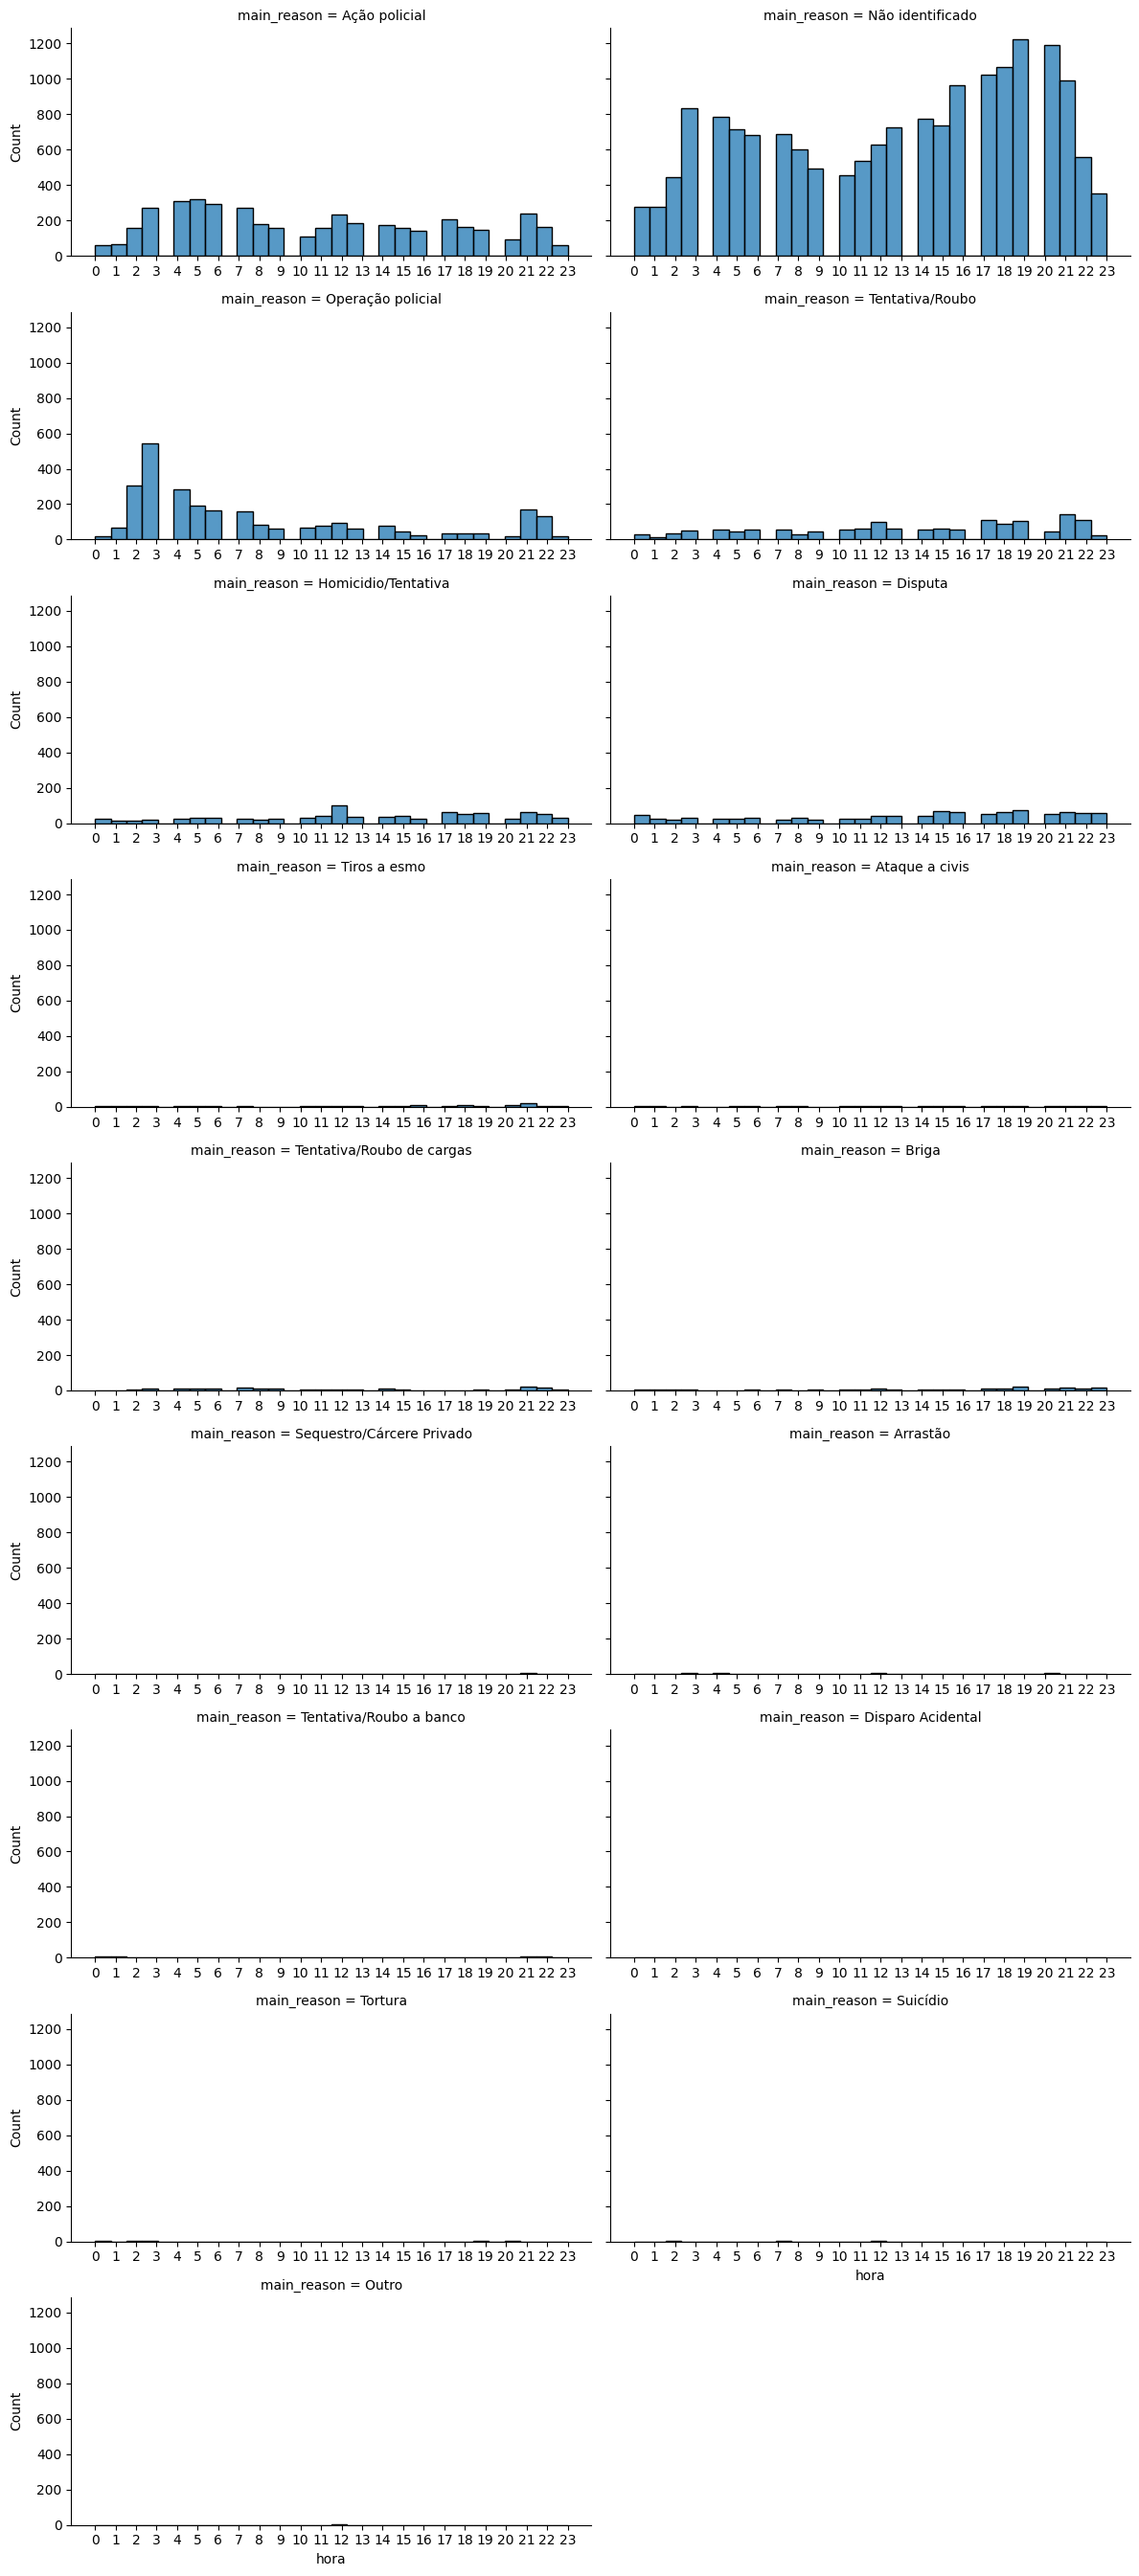

In [ ]:
g = sns.displot(
    data=crossfire_df,
    x="hora",
    col="main_reason",
    col_wrap=2,
    height=3,
    aspect=2
)

for ax in g.axes.flatten():
    ax.set_xticks(range(0, 24))
    ax.tick_params(labelbottom=True)

plt.xticks(range(0, 24))
plt.show()

In [ ]:
crossfire_df['hora'].value_counts() # Horarios com mais ocorrências

hora
3     1786
21    1741
19    1690
17    1520
4     1509
18    1497
20    1466
5     1351
16    1300
6     1291
7     1255
12    1242
14    1190
13    1138
15    1133
22    1130
2      999
8      963
11     925
9      828
10     758
23     574
0      491
1      485
Name: count, dtype: int64

In [ ]:
crossfire_df['hora'].value_counts().sort_index() #Ordenado por horário

hora
0      491
1      485
2      999
3     1786
4     1509
5     1351
6     1291
7     1255
8      963
9      828
10     758
11     925
12    1242
13    1138
14    1190
15    1133
16    1300
17    1520
18    1497
19    1690
20    1466
21    1741
22    1130
23     574
Name: count, dtype: int64

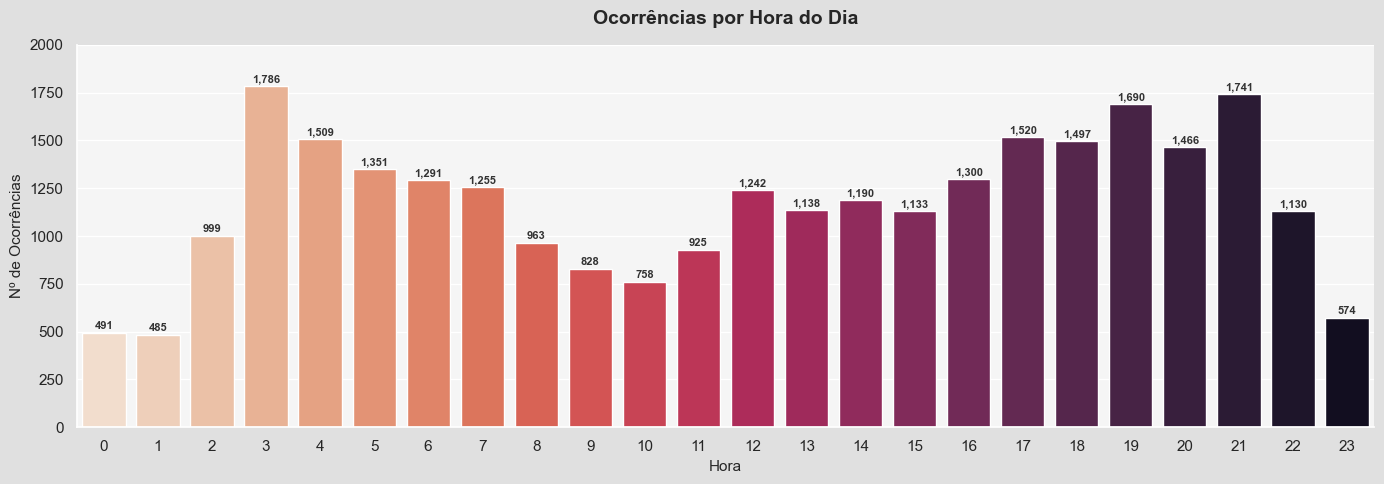

In [35]:
contagem_hora = crossfire_df['hora'].value_counts().reindex(range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
palette = sns.color_palette("rocket_r", n_colors=24)
sns.barplot(x=contagem_hora.index, y=contagem_hora.values, hue=contagem_hora.index, palette=palette, legend=False, ax=ax)

for bar, value in zip(ax.patches, contagem_hora.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f'{value:,}',
        ha='center', va='bottom',
        fontsize=8, fontweight='bold', color='#333333'
    )

ax.set_title('Ocorrências por Hora do Dia', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hora', fontsize=11)
ax.set_ylabel('Nº de Ocorrências', fontsize=11)
ax.set_ylim(0, contagem_hora.values.max() * 1.12)
ax.set_xticks(range(24))

fig.patch.set_facecolor("#e0e0e0")
ax.set_facecolor("#f5f5f5")
sns.despine()
plt.tight_layout()
plt.show()

### Encontramos uma distribuição bimodal nos dados!
Há picos as 3h e as 21h e um vale entre eles

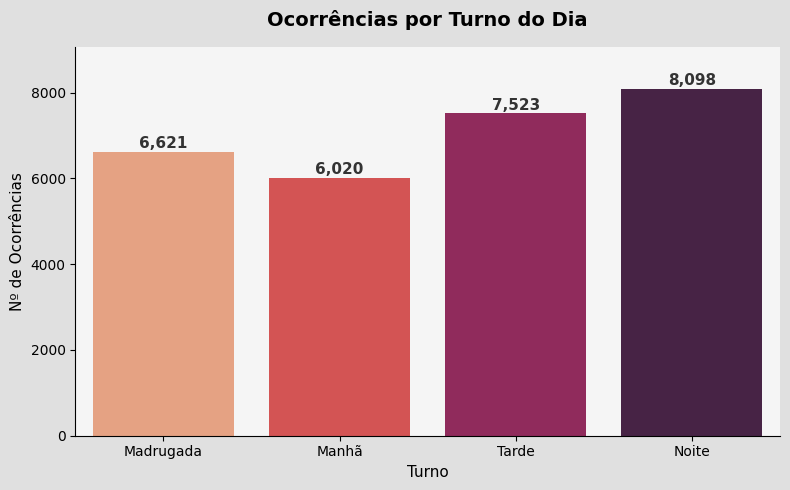

In [30]:
contagem = crossfire_df['turno'].value_counts().reindex(['Madrugada', 'Manhã', 'Tarde', 'Noite'])
fig, ax = plt.subplots(figsize=(8, 5))

palette = sns.color_palette("rocket_r", n_colors=4)

sns.barplot(x=contagem.index, y=contagem.values, hue=contagem.index, palette=palette, legend=False, ax=ax)

for bar, value in zip(ax.patches, contagem.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f'{value:,}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='#333333'
    )

ax.set_title('Ocorrências por Turno do Dia', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Turno', fontsize=11)
ax.set_ylabel('Nº de Ocorrências', fontsize=11)
ax.set_ylim(0, contagem.values.max() * 1.12)
fig.patch.set_facecolor("#e0e0e0")
ax.set_facecolor("#f5f5f5")
sns.despine()
plt.tight_layout()
plt.show()

### O turno mais comum é a noite!

<Axes: xlabel='longitude', ylabel='latitude'>

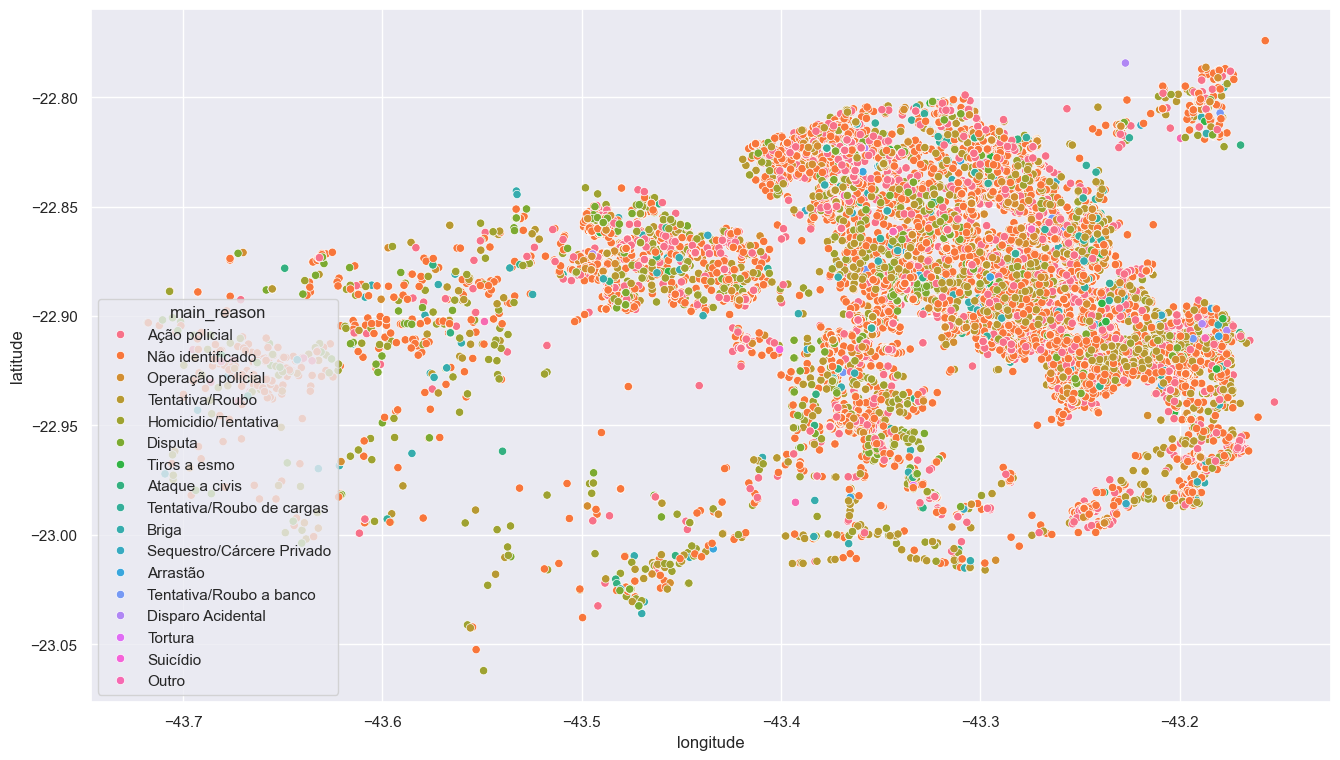

In [31]:
sns.set(rc={"figure.figsize": (16, 9)})
sns.scatterplot(x="longitude", y="latitude", hue="main_reason", data=crossfire_df)

### A maioria das ocorrências estão distribuidas no centro ou zona norte

In [32]:
mapa = folium.Map(location=[-22.9068, -43.1729], zoom_start=12)

# heat_data = crossfire_df[['latitude', 'longitude']].values.tolist()
# HeatMap(heat_data).add_to(mapa)

for ano, grupo in crossfire_df.groupby(crossfire_df["data_timestamp"].dt.year):
    heat_data = grupo[["latitude", "longitude"]].values.tolist()
    
    folium.FeatureGroup(name=str(ano)).add_child(
        HeatMap(heat_data)
    ).add_to(mapa)

folium.LayerControl().add_to(mapa)

mapa

## Com isso concluimos nossa AED, vimos quais dados eram necessários, quais não eram, quais features adicionar e a distribuição

### Pontos importantes:
- A maioria das ocorrências é a noite, porém não por muito;
- 60% das ocorrências tem causa não identificada, o que abre espaço para erros na análise;
- As ocorrências se concentram no Centro e Zona Norte;
- Quase 90% das ocorrências não possuem civis feridos e/ou mortos.

Os dados do Fogo cruzado possuem informações muito úteis, em especial a latitude e longitude da ocorrência, a maior granularidade possível. <br> 
Os dados que serão usados não possuem valores nulos ou mal formatados